<a href="https://colab.research.google.com/github/prottoy47-hub/clinical-trial-analysis/blob/main/AURKB_InSilico_QSAR_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Universal QSAR Pipeline — Interactive Notebook
### From ChEMBL Bioactivity Data to Docking Candidates

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/QSAR_Universal_Interactive.ipynb)

---

**Author:** *Santiago Bolivar*  
**Version:** 1.0  
**License:** MIT  

---

# 📚 What is QSAR? A Pedagogical Introduction

## The core idea

**QSAR** stands for **Quantitative Structure-Activity Relationship**. The central premise is elegant and powerful:

> *"Similar molecules tend to have similar biological activities."*

If we can describe a molecule as a set of numbers (called **molecular descriptors**), and we have experimental data on which molecules are active or inactive against a biological target, we can train a machine learning model to **learn the pattern** — and then use that model to predict the activity of molecules that have never been tested in a laboratory.

---

## Why does this matter?

Drug discovery is enormously expensive and slow. Testing millions of compounds in a wet lab takes years and costs hundreds of millions of dollars. Computational methods like QSAR allow researchers to:

- **Pre-filter** large chemical libraries, selecting only the most promising candidates for experimental testing
- **Identify the chemical features** that drive biological activity (Structure-Activity Relationship analysis)
- **Generate new molecules** by rationally modifying active scaffolds
- **Predict ADMET properties** (absorption, distribution, metabolism, excretion, toxicity) before synthesis

In this notebook, QSAR acts as an **intelligent filter** before molecular docking. Instead of docking hundreds of molecules blindly, you will dock only the top candidates ranked by the QSAR model.

---

## The QSAR workflow in plain language

```
Step 1: Collect data
   ChEMBL database → IC50 values for your target → "these molecules inhibit the protein"
   
Step 2: Convert molecules to numbers
   SMILES strings → molecular descriptors (200+ numerical properties)
   "CCO" → [MW=46, logP=-0.001, HBD=1, HBA=1, rings=0 ...]
   
Step 3: Train a classifier
   Machine learning model learns: what numerical patterns predict activity?
   
Step 4: Validate rigorously
   5-fold cross-validation + independent test set → is the model trustworthy?
   
Step 5: Screen your library
   Apply the model to YOUR molecules → probability of being active
   
Step 6: Interpret
   SHAP analysis → which properties matter most? (SAR)
```

---

## Key concepts you will encounter

### Molecular Descriptors
Numbers that encode chemical information. Examples:
- **Molecular weight (MW)**: size of the molecule
- **logP**: lipophilicity — how well the molecule crosses cell membranes
- **Topological Polar Surface Area (TPSA)**: related to oral absorption and membrane permeability
- **Morgan Fingerprints (ECFP4)**: binary vectors encoding local atomic environments — the molecule's "chemical fingerprint"

### Classification vs Regression
This notebook uses **binary classification**: molecules are labeled as **ACTIVE** (IC50 ≤ threshold) or **INACTIVE** (IC50 > threshold). This is more robust than regression (predicting exact IC50 values) when data from multiple labs is noisy.

### Applicability Domain (AD)
A critical concept for responsible QSAR. The model can only make reliable predictions for molecules **similar to those it was trained on**. The **Williams Plot** visualizes this: molecules with high leverage (far from the training set's chemical space) are flagged — their predictions are extrapolations and must be interpreted carefully.

### SHAP Values
SHAP (SHapley Additive exPlanations) answers: *"Why did the model predict this molecule is active?"* Each descriptor gets a SHAP value — positive means it contributes to activity, negative means it hurts activity. This is the bridge between QSAR and SAR (Structure-Activity Relationship).

---

## Model validation metrics — what to look for

| Metric | Formula | Interpretation | Good value |
|--------|---------|----------------|------------|
| **ROC-AUC** | Area under ROC curve | 0.5 = random, 1.0 = perfect | ≥ 0.75 |
| **MCC** | Matthews Correlation Coefficient | Best metric for imbalanced datasets | ≥ 0.4 |
| **Balanced Accuracy** | (Sensitivity + Specificity) / 2 | Unbiased accuracy for imbalanced data | ≥ 0.70 |
| **Sensitivity** | TP / (TP + FN) | Fraction of actives correctly identified | ≥ 0.65 |
| **Specificity** | TN / (TN + FP) | Fraction of inactives correctly rejected | ≥ 0.65 |

> **Important:** A model with AUC < 0.65 has limited predictive power. The screening results can still be reported but must be interpreted with caution and validated by docking.

---

## What results will you obtain?

At the end of this notebook, you will have:

1. **A trained QSAR model** validated on an independent test set
2. **Top N candidates** from your molecular library ranked by probability of activity
3. **Williams Plot** — showing which candidates are within the applicability domain
4. **SHAP/SAR analysis** — identifying the chemical properties that drive predicted activity
5. **ADMET profile** — drug-likeness assessment (Lipinski, Veber, PAINS alerts, QED)
6. **Generated analogs** — rational modifications of top candidates based on SAR insights
7. **A ZIP file** with all figures, tables, and SMILES ready for the next step

---

## How to interpret the results

### The probability score (p)
Each molecule gets a probability between 0 and 1. **This is NOT the probability of being a drug** — it is the model's confidence that the molecule resembles the active compounds in the training set.
- p ≥ 0.80: strong prediction of activity
- 0.60 ≤ p < 0.80: moderate prediction
- p < 0.60: weak prediction (not necessarily inactive — the model is uncertain)

### The Applicability Domain flag
- ✅ **Inside AD**: prediction is reliable — the molecule is similar to the training set
- ⚠️ **Outside AD**: prediction is an extrapolation — treat with caution but do not discard automatically. Many active natural products fall outside the AD of models trained on synthetic compounds.

### The SHAP summary plot
- Each dot is one molecule from your library
- Color: red = high value of that descriptor, blue = low value
- X-axis position: positive SHAP = increases predicted activity, negative = decreases it
- Example: if MolLogP has high positive SHAP for red dots → high lipophilicity favors activity

### ADMET flags
- **Ro5 violations**: 0-1 violations are acceptable for oral drugs; >1 suggests poor oral bioavailability unless the molecule is known to use active transport
- **PAINS alert**: structural patterns that cause assay interference. Not necessarily toxic — but be cautious and check in literature
- **QED ≥ 0.5**: generally drug-like profile

---

## ⚡ What to do AFTER this notebook

This notebook is **Step 1 of a multi-scale in silico pipeline**. The complete workflow is:

```
QSAR (this notebook)
    ↓
    Top N candidates selected
    ↓
Molecular Docking (AutoDock Vina / Glide)
    → Prepare receptor: remove water, add charges, define binding site grid
    → Convert SMILES to 3D: obabel -ismi candidates.smi -O candidates.sdf --gen3d
    → Run docking: vina --receptor receptor.pdbqt --ligand ligand.pdbqt --out result.pdbqt
    → Analyze: binding poses, hydrogen bonds with catalytic residues
    ↓
    Top 3-5 candidates from docking
    ↓
Molecular Dynamics (AMBER / GROMACS)
    → Parametrize ligand: GAFF2 force field
    → System preparation: solvate, neutralize, minimize, equilibrate
    → Production run: 100-200 ns
    → Analysis: RMSD, RMSF, hydrogen bond occupancy, binding pocket stability
    ↓
Binding Free Energy (MM-PBSA / MM-GBSA)
    → Calculate ΔGbind from MD trajectory
    → Per-residue decomposition → identify key interactions
    → Rank final candidates by binding free energy
    ↓
    Final 1-2 candidates for publication
```

### Recommendations for a publication-quality study

1. **Report model statistics clearly**: always include AUC, MCC, and balanced accuracy on the external test set — not just on cross-validation
2. **Report the applicability domain**: indicate which candidates are inside/outside the AD and discuss the implications
3. **Do not discard outside-AD candidates automatically**: validate them with docking; many bioactive natural products are structurally unique
4. **Connect SHAP to docking results**: if SHAP identifies logP as important and your docking shows hydrophobic interactions — that is consistent, publishable SAR
5. **Include ADMET in the paper**: reviewers will ask. At minimum report MW, logP, HBD, HBA, TPSA, Ro5 violations, and QED for all top candidates
6. **Use the SMILES for both enantiomers** if your molecules have stereocenters — docking is stereospecific
7. **Validate experimentally if possible**: even a single IC50 measurement for the top candidate enormously strengthens the paper

---

## 🗺️ Notebook structure at a glance

| Module | What it does | Time estimate |
|--------|-------------|---------------|
| **0** | Installation + Configuration | ~5 min (first run) |
| **1** | ChEMBL data download + curation | ~2 min |
| **2** | Descriptor calculation + model training | ~5-10 min |
| **3** | Library screening + Applicability Domain | ~3-5 min |
| **4A** | SAR analysis (SHAP) | ~3-8 min |
| **4B** | ADMET profile | ~1 min |
| **4C** | Analog generation | ~2 min |
| **5** | Export all results (ZIP) | ~1 min |

---

> **⚠️ Start here:** Run the installation cell in Module 0 first. It takes ~4 minutes on first run.

---
# MODULE 0 — Installation & Configuration

In [13]:
print('⏳ Installing dependencies... (~4 min on first run)')
!pip install -q rdkit chembl-webresource-client xgboost shap mols2grid
print('\n✅ Installation complete. Continue with the configuration cell below.')

⏳ Installing dependencies... (~4 min on first run)

✅ Installation complete. Continue with the configuration cell below.


In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns, warnings, io, zipfile, os, re
warnings.filterwarnings('ignore')

from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw, rdMolDescriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import FilterCatalog
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                              matthews_corrcoef, classification_report,
                              confusion_matrix, roc_curve)
from sklearn.feature_selection import VarianceThreshold
import xgboost as xgb, shap
from numpy.linalg import pinv
from google.colab import files

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
C = {'act':'#27ae60','inact':'#e74c3c','top':'#8e44ad','neu':'#2980b9','warn':'#e67e22'}

# ── Utility functions ────────────────────────────────────────────────────
def smiles_ok(s):
    """Returns True if SMILES string is chemically valid."""
    try: return Chem.MolFromSmiles(str(s)) is not None
    except: return False

def standardize(s):
    """Removes salts and counterions, returns canonical parent fragment."""
    try:
        m = Chem.MolFromSmiles(str(s))
        if m is None: return None
        return Chem.MolToSmiles(rdMolStandardize.LargestFragmentChooser().choose(m))
    except: return None

calc_rdkit = MoleculeDescriptors.MolecularDescriptorCalculator(
    [d[0] for d in Descriptors.descList])
DESC_NAMES = list(calc_rdkit.GetDescriptorNames())

def get_descriptors(s):
    """Calculates all 2D RDKit descriptors for a SMILES string."""
    try:
        m = Chem.MolFromSmiles(str(s))
        return list(calc_rdkit.CalcDescriptors(m)) if m else [np.nan]*len(DESC_NAMES)
    except: return [np.nan]*len(DESC_NAMES)

def leverage(X_ref, X_query):
    """Calculates hat values (leverage) for applicability domain assessment."""
    inv = pinv(X_ref.T @ X_ref)
    return np.array([x @ inv @ x for x in X_query])

# Global state dictionary — stores all results between cells
STATE = {}
print('✅ Libraries loaded and utility functions defined.')
print(f'   RDKit descriptors available: {len(DESC_NAMES)}')

✅ Libraries loaded and utility functions defined.
   RDKit descriptors available: 217


---
## How to find your ChEMBL Target ID

You have two options:

**Option A — Search by name (recommended if you don't know the ID):**  
Run the cell below. Type a protein name and ChEMBL will return matching targets. Copy the `target_chembl_id` of the one you want.

**Option B — Search on the web:**  
1. Go to [https://www.ebi.ac.uk/chembl/](https://www.ebi.ac.uk/chembl/)
2. Type your protein name in the search bar (e.g., `dengue protease`, `EGFR kinase`, `HIV protease`)
3. Click the **Targets** tab
4. Find the target that matches yours and copy the `CHEMBL_______` code

> **Tip:** Prefer targets of type `SINGLE PROTEIN` over `ORGANISM` — they contain more specific, higher-confidence bioactivity data.

In [15]:
# ── Option A: Search by protein/disease name ─────────────────────────────
# Change the search term below to find your target
SEARCH_TERM = 'AURKB'    # ← CHANGE THIS

print(f'🔍 Searching ChEMBL for: "{SEARCH_TERM}"\n')
target_api = new_client.target
results = target_api.search(SEARCH_TERM)
df_targets = pd.DataFrame(list(results))[
    ['target_chembl_id','pref_name','target_type','organism']
].head(15)

print(f'Found {len(df_targets)} targets:\n')
display(df_targets)
print('\n💡 Copy the target_chembl_id you want and paste it in the configuration cell below.')

🔍 Searching ChEMBL for: "AURKB"

Found 8 targets:



,target_chembl_id,pref_name,target_type,organism
0,CHEMBL2176838,Aurora kinase B-A,SINGLE PROTEIN,Xenopus laevis
1,CHEMBL3638361,Aurora kinase B-B,SINGLE PROTEIN,Xenopus laevis
2,CHEMBL2185,Aurora kinase B,SINGLE PROTEIN,Homo sapiens
3,CHEMBL1075275,Aurora kinase B,SINGLE PROTEIN,Mus musculus
4,CHEMBL3430907,Aurora kinase B/Inner centromere protein,PROTEIN COMPLEX,Homo sapiens
5,CHEMBL3430908,Aurora kinase B/Receptor-type tyrosine-protein...,SELECTIVITY GROUP,Homo sapiens
6,CHEMBL3883303,Aurora kinase A/B,PROTEIN FAMILY,Homo sapiens
7,CHEMBL3430911,Serine/threonine-protein kinase Aurora,PROTEIN FAMILY,Homo sapiens



💡 Copy the target_chembl_id you want and paste it in the configuration cell below.


In [16]:
# ════════════════════════════════════════════════════════════════════════
#   MAIN CONFIGURATION — EDIT THESE VALUES
# ════════════════════════════════════════════════════════════════════════

# ── Therapeutic target ──────────────────────────────────────────────────
# Paste the ChEMBL ID from the search above (or from the ChEMBL website)
TARGET_ID   = 'CHEMBL2185'          # ← CHANGE: e.g. 'CHEMBL612545' for HIV-1 Protease
TARGET_NAME = 'Human AURKB'       # ← CHANGE: used in figure titles

# ── Activity type ───────────────────────────────────────────────────────
# Common options: 'IC50', 'Ki', 'EC50', 'Kd'
# IC50: concentration inhibiting 50% activity (most common in ChEMBL)
# Ki:   inhibition constant (more thermodynamically rigorous, fewer data points)
ACTIVITY_TYPE = 'IC50'                # ← CHANGE if your target has more Ki data

# ── Activity cutoff ─────────────────────────────────────────────────────
# Molecules with value <= THRESHOLD_nM will be labeled ACTIVE
# Typical values:
#     100 nM  → strict (only highly potent compounds)
#    1000 nM  → stringent (potent compounds)
#   10000 nM  → standard (most in silico studies use this)
#  100000 nM  → broad (captures more actives, more noise)
THRESHOLD_nM = 1000                  # ← CHANGE according to your criteria

# ── Number of top candidates ────────────────────────────────────────────
TOP_N = 15                            # ← CHANGE: how many final candidates you want

# ── Optional modules ────────────────────────────────────────────────────
RUN_ADMET   = True    # True/False: Lipinski + Veber + PAINS + QED profile
RUN_ANALOGS = True    # True/False: generate analogs of Top 5 by scaffold modification

# ════════════════════════════════════════════════════════════════════════
STATE['config'] = {
    'target_id': TARGET_ID, 'target_name': TARGET_NAME,
    'activity_type': ACTIVITY_TYPE, 'threshold': THRESHOLD_nM,
    'top_n': TOP_N, 'admet': RUN_ADMET, 'analogs': RUN_ANALOGS
}

print('✅ Configuration saved:\n')
print(f'   Target:           {TARGET_ID} ({TARGET_NAME})')
print(f'   Activity type:    {ACTIVITY_TYPE}')
print(f'   Activity cutoff:  ≤ {THRESHOLD_nM:,} nM = ACTIVE')
print(f'   Top candidates:   {TOP_N}')
print(f'   ADMET module:     {"enabled" if RUN_ADMET else "disabled"}')
print(f'   Analogs module:   {"enabled" if RUN_ANALOGS else "disabled"}')

print('\n📋 Quick reference — common targets:')
ref = [
    ('Dengue NS2B-NS3 protease', 'CHEMBL613966', 'IC50', 10000),
    ('HIV-1 Protease',           'CHEMBL612545', 'IC50', 1000),
    ('SARS-CoV-2 Mpro',          'CHEMBL4523582','IC50', 10000),
    ('Plasmodium PfDHFR',        'CHEMBL3718',   'IC50', 1000),
    ('EGFR Kinase',              'CHEMBL203',    'IC50', 100),
    ('COX-2',                    'CHEMBL230',    'IC50', 1000),
    ('Leishmania TDR1',          'CHEMBL1741203','IC50', 10000),
]
df_ref = pd.DataFrame(ref, columns=['Target','ChEMBL ID','Activity','Cutoff (nM)'])
display(df_ref)

✅ Configuration saved:

   Target:           CHEMBL2185 (Human AURKB)
   Activity type:    IC50
   Activity cutoff:  ≤ 1,000 nM = ACTIVE
   Top candidates:   15
   ADMET module:     enabled
   Analogs module:   enabled

📋 Quick reference — common targets:


,Target,ChEMBL ID,Activity,Cutoff (nM)
0,Dengue NS2B-NS3 protease,CHEMBL613966,IC50,10000
1,HIV-1 Protease,CHEMBL612545,IC50,1000
2,SARS-CoV-2 Mpro,CHEMBL4523582,IC50,10000
3,Plasmodium PfDHFR,CHEMBL3718,IC50,1000
4,EGFR Kinase,CHEMBL203,IC50,100
5,COX-2,CHEMBL230,IC50,1000
6,Leishmania TDR1,CHEMBL1741203,IC50,10000


---
# MODULE 1 — ChEMBL Dataset Download & Curation

## Why data curation matters

ChEMBL aggregates bioactivity data from thousands of publications. This means:
- The same compound may have been tested in multiple labs under different conditions
- Values with `>` or `<` relations (e.g., IC50 > 100 µM) are censored data — upper/lower bounds, not true measurements
- Some SMILES strings may be invalid or contain salts that need to be removed

The curation pipeline below addresses all of these issues systematically. Losing molecules in this step is expected and necessary — a smaller, high-quality dataset produces better models than a larger, noisy one.

In [17]:
cfg = STATE['config']
print(f'📡 Downloading ChEMBL data for {cfg["target_id"]} ({cfg["target_name"]})...')

act_api = new_client.activity
activities = act_api.filter(
    target_chembl_id=cfg['target_id'],
    standard_type=cfg['activity_type']
).only(['molecule_chembl_id','canonical_smiles','standard_value',
        'standard_relation','pchembl_value','document_year',
        'assay_type','assay_description'])

df_raw = pd.DataFrame(list(activities))
print(f'\n✅ Downloaded: {len(df_raw)} {cfg["activity_type"]} records')

if len(df_raw) == 0:
    print('\n❌ No data found. Please check:')
    print('   1. Is the TARGET_ID correct?')
    print('   2. Try changing ACTIVITY_TYPE to "Ki" or "EC50"')
    print('   3. Verify the target has bioactivity data on chembl.ebi.ac.uk')
elif len(df_raw) < 30:
    print(f'\n⚠️  Only {len(df_raw)} records found — dataset may be too small for a robust model.')
    print('   Consider: changing activity type, using a related target, or adjusting the threshold.')
else:
    years = df_raw['document_year'].dropna().astype(int)
    print(f'   Publication years: {years.min()} – {years.max()}')
    print(f'   Assay types: {df_raw["assay_type"].value_counts().to_dict()}')

📡 Downloading ChEMBL data for CHEMBL2185 (Human AURKB)...

✅ Downloaded: 3248 IC50 records
   Publication years: 2003 – 2024
   Assay types: {'B': 3213, 'A': 30, 'F': 5}


[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragmentChooser
[18:44:14] Running LargestFragment

=== CURATION REPORT ===
  Step                                              Before →   After    Lost
  ------------------------------------------------------------------------
  Keep exact measurements only (=)                    3248 →    2211  (-1037)
  Remove NaN (SMILES + value)                         2211 →    2210  (   -1)
  Validate SMILES with RDKit                          2210 →    2210  (   +0)
  Standardize / remove salts                          2210 →    2210  (   +0)
  Deduplicate (median per molecule)                   2210 →    1888  ( -322)
  ------------------------------------------------------------------------
  Final dataset: 1888 unique molecules
  ACTIVE   (≤1,000 nM): 1450 (76.8%)
  INACTIVE (>1,000 nM): 438 (23.2%)
  Imbalance ratio: 0.30:1


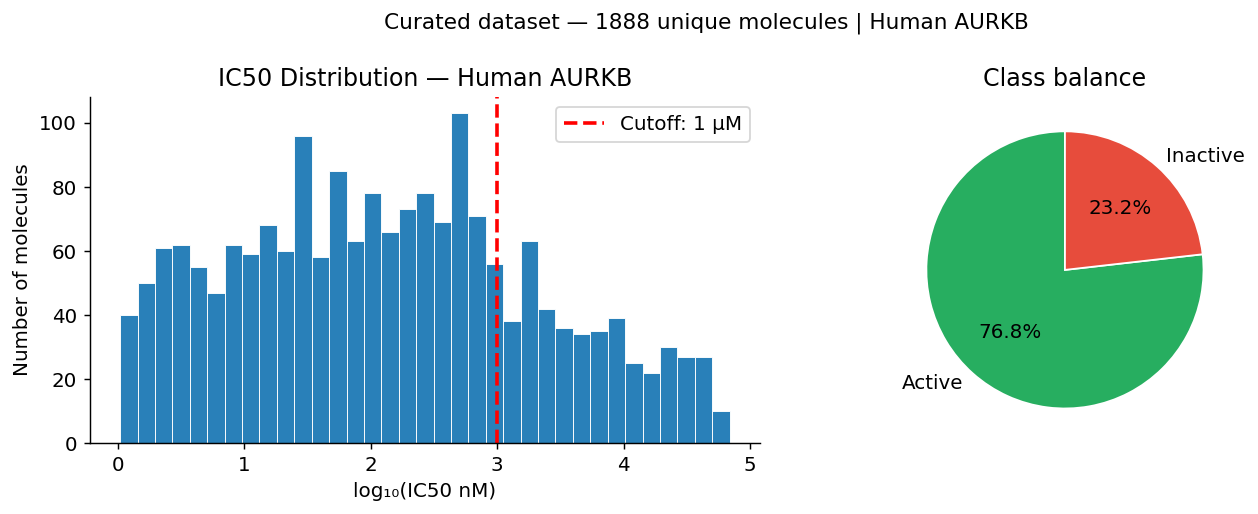

✅ Figure saved: 01_dataset.png


In [18]:
# ── Data Curation Pipeline ───────────────────────────────────────────────
n0 = len(df_raw)
steps_log = []

# Step 1: Keep only exact measurements (relation = '=')
df = df_raw[df_raw['standard_relation'] == '='].copy()
steps_log.append(('Keep exact measurements only (=)', n0, len(df)))

# Step 2: Remove missing values
df = df.dropna(subset=['canonical_smiles','standard_value'])
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna(subset=['standard_value'])
steps_log.append(('Remove NaN (SMILES + value)', steps_log[-1][2], len(df)))

# Step 3: Validate SMILES
df = df[df['canonical_smiles'].apply(smiles_ok)].copy()
steps_log.append(('Validate SMILES with RDKit', steps_log[-1][2], len(df)))

# Step 4: Standardize structures (remove salts)
df['smiles_std'] = df['canonical_smiles'].apply(standardize)
df = df.dropna(subset=['smiles_std'])
steps_log.append(('Standardize / remove salts', steps_log[-1][2], len(df)))

# Step 5: Deduplicate — same molecule tested multiple times → take median
df_train = df.groupby('molecule_chembl_id').agg(
    smiles_std=('smiles_std','first'),
    activity_nM=('standard_value','median'),
    n_measurements=('standard_value','count')
).reset_index()
steps_log.append(('Deduplicate (median per molecule)', steps_log[-1][2], len(df_train)))

# Step 6: Assign binary labels
df_train['y'] = (df_train['activity_nM'] <= cfg['threshold']).astype(int)
n_act = df_train['y'].sum()
n_inact = (df_train['y']==0).sum()

print('=== CURATION REPORT ===')
print(f'  {"Step":<48} {"Before":>7} → {"After":>7}  {"Lost":>6}')
print('  ' + '-'*72)
for step, before, after in steps_log:
    lost = before - after
    print(f'  {step:<48} {before:>7} → {after:>7}  ({-lost:>+5})')
print('  ' + '-'*72)
print(f'  Final dataset: {len(df_train)} unique molecules')
print(f'  ACTIVE   (≤{cfg["threshold"]:,} nM): {n_act} ({100*n_act/len(df_train):.1f}%)')
print(f'  INACTIVE (>{cfg["threshold"]:,} nM): {n_inact} ({100*n_inact/len(df_train):.1f}%)')
print(f'  Imbalance ratio: {n_inact/max(n_act,1):.2f}:1')

STATE['df_train'] = df_train

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(np.log10(df_train['activity_nM']+1), bins=35,
             color=C['neu'], edgecolor='white', linewidth=0.5)
axes[0].axvline(np.log10(cfg['threshold']), color='red', ls='--', lw=2,
                label=f'Cutoff: {cfg["threshold"]/1000:.0f} µM')
axes[0].set_xlabel(f'log₁₀({cfg["activity_type"]} nM)')
axes[0].set_ylabel('Number of molecules')
axes[0].set_title(f'{cfg["activity_type"]} Distribution — {cfg["target_name"]}')
axes[0].legend()
axes[1].pie([n_act, n_inact], labels=['Active','Inactive'],
            colors=[C['act'],C['inact']], autopct='%1.1f%%', startangle=90,
            wedgeprops={'linewidth':1,'edgecolor':'white'})
axes[1].set_title('Class balance')
plt.suptitle(f'Curated dataset — {len(df_train)} unique molecules | {cfg["target_name"]}',
             fontsize=12)
plt.tight_layout()
plt.savefig('01_dataset.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 01_dataset.png')

---
# MODULE 2 — Descriptors & QSAR Model

## The descriptor calculation step

RDKit calculates ~200 two-dimensional descriptors for each molecule. These capture:
- **Constitutional descriptors**: molecular weight, atom counts, bond counts
- **Topological descriptors**: Wiener index, Zagreb index, connectivity indices
- **Electronic descriptors**: TPSA, partial charges, electron accessibility
- **Lipophilicity**: logP, logD estimates
- **Fragment-based**: H-bond donors/acceptors, rotatable bonds, ring counts

## Feature selection

Not all descriptors are informative. We apply three filters:
1. **NaN filter**: remove descriptors that cannot be calculated for >20% of molecules
2. **Variance filter**: remove descriptors with zero variance (constant values — no information)
3. **Correlation filter**: remove redundant descriptors (Pearson r > 0.95 with another descriptor)

## Why three ML algorithms?

| Algorithm | Strength | Best when |
|-----------|----------|----------|
| **Random Forest** | Robust, interpretable, handles small datasets | < 500 molecules |
| **XGBoost** | High accuracy, handles class imbalance | 200–2000 molecules |
| **SVM (RBF)** | Excellent with small data, captures non-linearity | < 300 molecules |

In [19]:
df_train = STATE['df_train']
cfg = STATE['config']

print('Calculating molecular descriptors (this may take 1-3 min)...')
X_raw = pd.DataFrame(df_train['smiles_std'].apply(get_descriptors).tolist(),
                     columns=DESC_NAMES)
y = df_train['y'].values
print(f'Initial matrix: {X_raw.shape[0]} molecules × {X_raw.shape[1]} descriptors')

# ── Feature selection ────────────────────────────────────────────────────
print('\nApplying feature selection filters...')
nan_frac = X_raw.isnull().mean()
X_f = X_raw[nan_frac[nan_frac <= 0.20].index].copy()
print(f'  After NaN >20% filter:       {X_f.shape[1]} descriptors')

medians = X_f.median()
X_f = X_f.fillna(medians)

vt = VarianceThreshold(0.0); vt.fit(X_f)
X_f = X_f.loc[:, vt.get_support()]
print(f'  After zero-variance filter:  {X_f.shape[1]} descriptors')

corr = X_f.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_c = [c for c in upper.columns if any(upper[c] > 0.95)]
X_f = X_f.drop(columns=drop_c)
print(f'  After correlation >0.95 filter: {X_f.shape[1]} descriptors')

FEATURES = X_f.columns.tolist()
STATE['features'] = FEATURES
STATE['medians']  = medians

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_f.values)
STATE['scaler'] = scaler
STATE['X_sc']   = X_sc
STATE['y']      = y

print(f'\n✅ Final feature set: {len(FEATURES)} descriptors')
print(f'   Training matrix ready: {X_sc.shape}')

Calculating molecular descriptors (this may take 1-3 min)...
Initial matrix: 1888 molecules × 217 descriptors

Applying feature selection filters...
  After NaN >20% filter:       217 descriptors
  After zero-variance filter:  201 descriptors
  After correlation >0.95 filter: 165 descriptors

✅ Final feature set: 165 descriptors
   Training matrix ready: (1888, 165)


Running 5-fold stratified cross-validation (may take 2-5 min)...

🥇 Random Forest           AUC=0.889±0.021  BAcc=0.729  MCC=0.541
   XGBoost                 AUC=0.888±0.024  BAcc=0.786  MCC=0.586
   SVM (RBF)               AUC=0.864±0.022  BAcc=0.788  MCC=0.530

🏆 Best model: Random Forest (AUC=0.889)


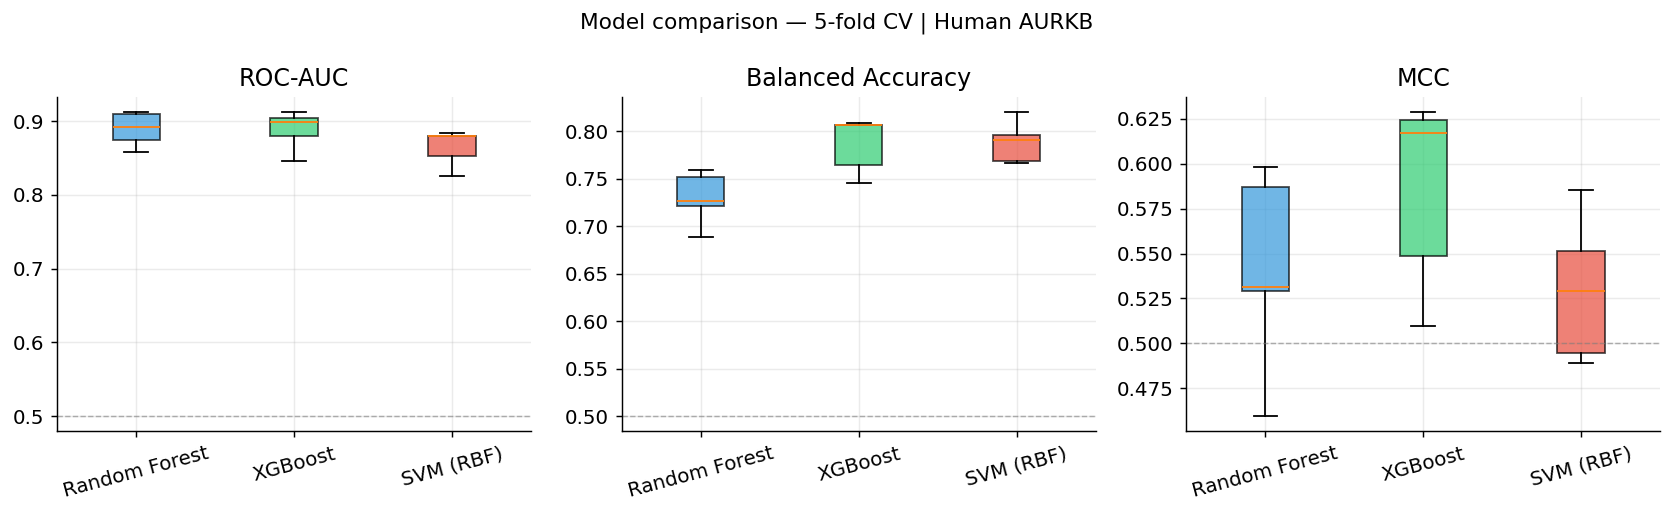

✅ Figure saved: 02_models_comparison.png


In [20]:
# ── Model Training & Cross-Validation ────────────────────────────────────
X_sc = STATE['X_sc']; y = STATE['y']; cfg = STATE['config']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y, test_size=0.20, stratify=y, random_state=42)

imbalance_ratio = (y_tr==0).sum() / max(y_tr.sum(), 1)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=imbalance_ratio, eval_metric='logloss',
        random_state=42, verbosity=0),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced',
                     probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold stratified cross-validation (may take 2-5 min)...\n')
for name, model in models.items():
    auc  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='roc_auc',          n_jobs=-1)
    bacc = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    mcc  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='matthews_corrcoef', n_jobs=-1)
    cv_results[name] = {'AUC':auc, 'BAcc':bacc, 'MCC':mcc}
    best_so_far = name == max(cv_results, key=lambda k: cv_results[k]['AUC'].mean())
    icon = '🥇' if best_so_far else '  '
    print(f'{icon} {name:<22}  AUC={auc.mean():.3f}±{auc.std():.3f}  '
          f'BAcc={bacc.mean():.3f}  MCC={mcc.mean():.3f}')

best_model_name = max(cv_results, key=lambda k: cv_results[k]['AUC'].mean())
print(f'\n🏆 Best model: {best_model_name} (AUC={cv_results[best_model_name]["AUC"].mean():.3f})')

STATE['cv_results'] = cv_results
STATE['best_name']  = best_model_name
STATE['models']     = models
STATE['X_tr'] = X_tr; STATE['X_te'] = X_te
STATE['y_tr'] = y_tr; STATE['y_te'] = y_te

# Comparison plot
fig, axes = plt.subplots(1, 3, figsize=(13,4))
model_colors = ['#3498db','#2ecc71','#e74c3c']
for ax, metric, title in zip(axes, ['AUC','BAcc','MCC'],
                              ['ROC-AUC','Balanced Accuracy','MCC']):
    data = [cv_results[m][metric] for m in models]
    bp = ax.boxplot(data, labels=list(models.keys()), patch_artist=True)
    for patch, col in zip(bp['boxes'], model_colors):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6, label='Random')
    ax.set_title(title); ax.grid(True, alpha=0.25)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle(f'Model comparison — 5-fold CV | {cfg["target_name"]}', fontsize=12)
plt.tight_layout()
plt.savefig('02_models_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 02_models_comparison.png')

EXTERNAL TEST SET EVALUATION (20% held out) — Random Forest
              precision    recall  f1-score   support

    Inactive      0.778     0.477     0.592        88
      Active      0.858     0.959     0.906       290

    accuracy                          0.847       378
   macro avg      0.818     0.718     0.749       378
weighted avg      0.839     0.847     0.832       378

  ROC-AUC:           0.875
  Balanced Accuracy: 0.718
  MCC:               0.526

✅ Good predictive power (AUC=0.875 ≥ 0.75) — model is suitable for screening


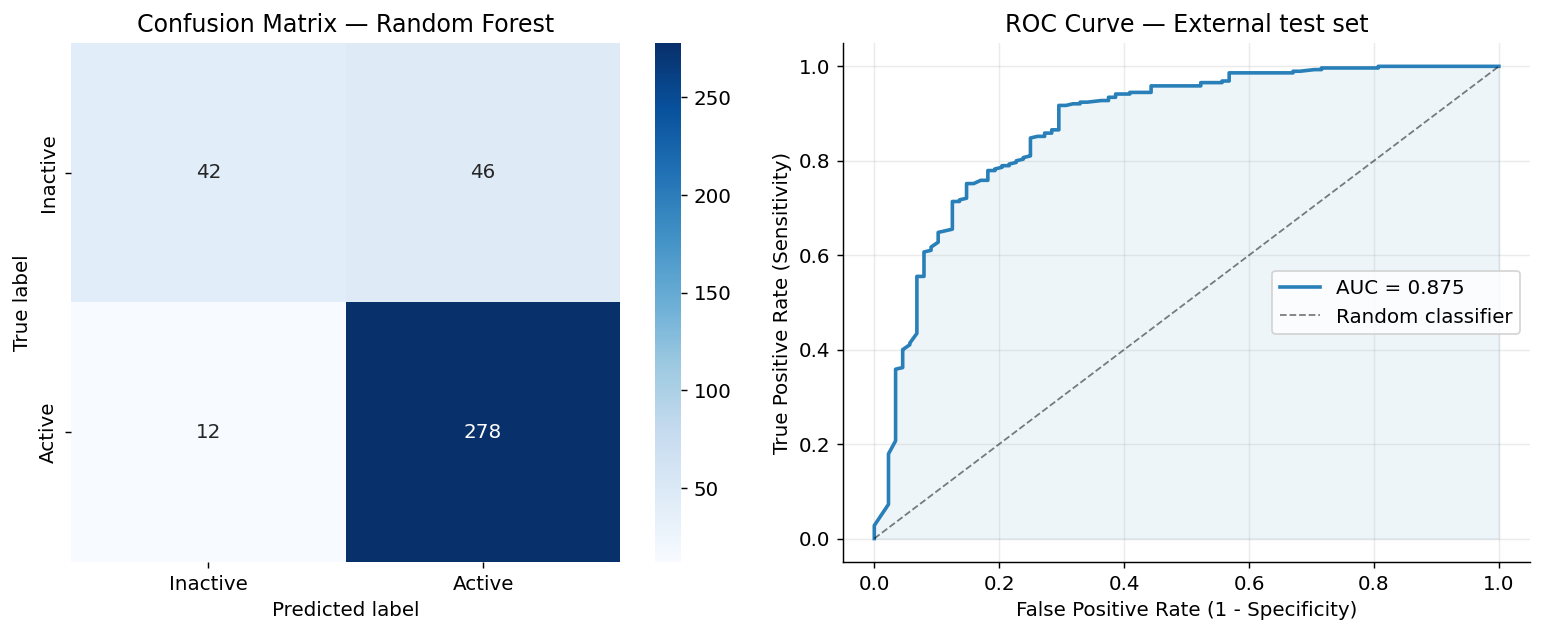

✅ Figure saved: 03_test_evaluation.png


In [21]:
# ── Final evaluation on external test set ───────────────────────────────
best_name  = STATE['best_name']
best_model = STATE['models'][best_name]
X_tr = STATE['X_tr']; X_te = STATE['X_te']
y_tr = STATE['y_tr']; y_te = STATE['y_te']

best_model.fit(X_tr, y_tr)
y_pred_te = best_model.predict(X_te)
y_prob_te = best_model.predict_proba(X_te)[:,1]

auc_te  = roc_auc_score(y_te, y_prob_te)
mcc_te  = matthews_corrcoef(y_te, y_pred_te)
bacc_te = balanced_accuracy_score(y_te, y_pred_te)

print(f'EXTERNAL TEST SET EVALUATION (20% held out) — {best_name}')
print('='*60)
print(classification_report(y_te, y_pred_te,
      target_names=['Inactive','Active'], digits=3))
print(f'  ROC-AUC:           {auc_te:.3f}')
print(f'  Balanced Accuracy: {bacc_te:.3f}')
print(f'  MCC:               {mcc_te:.3f}')

if auc_te >= 0.75:
    print(f'\n✅ Good predictive power (AUC={auc_te:.3f} ≥ 0.75) — model is suitable for screening')
elif auc_te >= 0.65:
    print(f'\n⚠️  Moderate predictive power (AUC={auc_te:.3f}) — use screening results with caution')
else:
    print(f'\n❌ Limited predictive power (AUC={auc_te:.3f} < 0.65) — consider adjusting threshold or target')

# Retrain on full dataset for screening
best_model.fit(STATE['X_sc'], STATE['y'])
STATE['best_model'] = best_model
STATE['test_metrics'] = {'auc': auc_te, 'mcc': mcc_te, 'bacc': bacc_te}

fig, axes = plt.subplots(1, 2, figsize=(12,5))
cm = confusion_matrix(y_te, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted label')
fpr, tpr, _ = roc_curve(y_te, y_prob_te)
axes[1].plot(fpr, tpr, lw=2, color=C['neu'], label=f'AUC = {auc_te:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.08, color=C['neu'])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve — External test set')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('03_test_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure saved: 03_test_evaluation.png')

---
# MODULE 3 — Library Screening & Applicability Domain

## Applicability Domain — the concept

The Applicability Domain (AD) defines the chemical space in which the model's predictions are reliable. A molecule **outside the AD** is structurally dissimilar from the training set — its prediction is an extrapolation.

We use the **leverage method** (Williams Plot):
- **Hat value (h)**: measures how far a molecule is from the centroid of the training set in descriptor space
- **Threshold h* = 3(k+1)/n**: where k = number of features, n = training set size
- Molecules with h > h* are flagged as outside the AD

**Important:** being outside the AD does NOT mean inactive. It means the model has limited basis to make that specific prediction. Always cross-validate with docking.

## Your CSV format
Your library file needs at minimum one column with SMILES strings. The column name is auto-detected if it matches: `SMILES`, `smiles`, `Canonical_SMILES`, `structure`, `mol`, or similar variants. An ID/name column is also auto-detected.

In [30]:
import os
from google.colab import drive

# Ensure Drive is mounted for this specific session
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# List files in MyDrive to find the exact filename/path
drive_path = '/content/drive/MyDrive/'
print("📂 Searching for your library in Drive...")
files_in_drive = os.listdir(drive_path)

# Look for the file
if 'AURKB_Q1_Library.csv' in files_in_drive:
    print("✅ Found it! The path is correct: /content/drive/MyDrive/AURKB_Q1_Library.csv")
else:
    print("❌ Not found in root. Checking sub-folders...")
    # This searches common folders like 'Colab Notebooks'
    for root, dirs, files in os.walk(drive_path):
        if 'AURKB_Q1_Library.csv' in files:
            full_path = os.path.join(root, 'AURKB_Q1_Library.csv')
            print(f"📍 Found it here: {full_path}")
            print("--- ACTION: Please update 'file_path' in your loading code to this new path. ---")
            break

Mounted at /content/drive
📂 Searching for your library in Drive...
✅ Found it! The path is correct: /content/drive/MyDrive/AURKB_Q1_Library.csv


In [31]:
import pandas as pd
import os

# UPDATE THIS PATH based on the output from the script above
file_path = '/content/drive/MyDrive/AURKB_Q1_Library.csv'

if os.path.exists(file_path):
    df_lib = pd.read_csv(file_path, low_memory=False)

    col_smi = 'canonical_smiles'
    col_id = 'identifier'

    print(f'\n✅ Library Loaded: {len(df_lib):,} compounds ready for screening.')

    # Store in STATE for the next modules
    STATE['df_lib_raw'] = df_lib
    STATE['col_smi'] = col_smi
    STATE['col_id']  = col_id
    display(df_lib.head(3))
else:
    print("❌ Path still invalid. Use the 'Folder' icon in the left sidebar to manually copy the path.")


✅ Library Loaded: 73,927 compounds ready for screening.


,identifier,canonical_smiles,standard_inchi,standard_inchi_key,name,iupac_name,annotation_level,total_atom_count,heavy_atom_count,molecular_weight,...,direct_parent_classification,np_classifier_pathway,np_classifier_superclass,np_classifier_class,np_classifier_is_glycoside,organisms,collections,dois,synonyms,cas
0,CNP0266711.4,OCC1O[C@@H](OC2=CC=C3C(=C2)OC[C@@H]2C4=CC5=C(C...,InChI=1S/C22H22O10/c23-6-17-18(24)19(25)20(26)...,VGSYCWGXBYZLLE-IIIJXXBKSA-N,Sophojaponicin,"(3~{S},4~{S},6~{S})-2-(hydroxymethyl)-6-[[(1~{...",3,54,32,446.41,...,Pterocarpans,Shikimates and Phenylpropanoids,Isoflavonoids,Pterocarpan,True,Sophora alopecuroides|Sophora flavescens|Sopho...,CMAUP (cCollective molecular activities of use...,NaN,(+)-Maackiain 3-O-glucoside|LMPK12070032,NaN
1,CNP0367999.1,C=CCC1N(CC2=CC=CC=C2)C(=O)[C@@H]2C(C(=O)O)[C@H...,InChI=1S/C19H19NO4/c1-2-6-14-19-10-9-13(24-19)...,RUHYDWNDMDUEBL-GDWAVCMYSA-N,STL547161,"(1~{S},5~{R},7~{R})-2-allyl-3-benzyl-4-oxo-10-...",2,43,24,325.36,...,Isoindolones,Alkaloids,NaN,NaN,False,NaN,InterBioScreen Ltd,NaN,"(3aS,6R,7aR)-2-benzyl-1-oxo-3-(prop-2-en-1-yl)...",NaN
2,CNP0104026.0,COC1=CC=C(C2=COC3=CC(OC(=O)C(C)(C)C)=CC=C3C2=O...,"InChI=1S/C22H22O6/c1-22(2,3)21(24)28-14-7-8-15...",UJGCZIIQFAJMJO-UHFFFAOYSA-N,738601-21-3,"[3-(3,4-dimethoxyphenyl)-4-oxo-chromen-7-yl] 2...",3,50,28,382.41,...,Isoflavones,Shikimates and Phenylpropanoids,Isoflavonoids,Isoflavones,False,NaN,InterBioScreen Ltd|Super Natural II,NaN,"3-(3,4-dimethoxyphenyl)-4-oxo-4H-chromen-7-yl ...",NaN


In [33]:
import numpy as np

# 1. Check where we left off
if os.path.exists(OUTPUT_PATH):
    processed_df = pd.read_csv(OUTPUT_PATH)
    start_index = len(processed_df)
    print(f"🔄 Resuming from molecule {start_index}...")
else:
    start_index = 0

# 2. Updated Batch Processing Loop
for i in range(start_index, len(df_lib), BATCH_SIZE):
    batch = df_lib.iloc[i : i + BATCH_SIZE].copy()

    # Descriptor Calculation
    X_raw = pd.DataFrame(batch['smiles_std'].apply(get_descriptors).tolist(), columns=DESC_NAMES)

    # --- THE FIX ---
    # Convert Infinity to NaN so the scaler doesn't crash
    X_f = X_raw[FEATURES].replace([np.inf, -np.inf], np.nan)
    X_f = X_f.fillna(medians[FEATURES])
    # ----------------

    X_sc_batch = scaler.transform(X_f.values)

    # Predictions
    probs = best_model.predict_proba(X_sc_batch)[:, 1]
    preds = (probs >= 0.5).astype(int)

    # Applicability Domain
    h_batch = leverage(STATE['X_sc'], X_sc_batch)
    h_star = 3 * (STATE['X_sc'].shape[1] + 1) / STATE['X_sc'].shape[0]
    in_ad = h_batch <= h_star

    # Save Batch
    batch_res = pd.DataFrame({
        'identifier': batch[col_id].values if col_id else [f'Mol_{j}' for j in range(i, i+len(batch))],
        'smiles': batch['smiles_std'].values,
        'prob_active': probs.round(4),
        'prediction': preds,
        'leverage': h_batch.round(4),
        'inside_AD': in_ad
    })

    is_first = not os.path.exists(OUTPUT_PATH)
    batch_res.to_csv(OUTPUT_PATH, mode='a', index=False, header=is_first)

    print(f"✅ Processed {min(i + BATCH_SIZE, len(df_lib))} / {len(df_lib)} molecules.")

print(f"🏁 Screening complete! Saved to: {OUTPUT_PATH}")

🔄 Resuming from molecule 30000...
✅ Processed 35000 / 73926 molecules.
✅ Processed 40000 / 73926 molecules.
✅ Processed 45000 / 73926 molecules.
✅ Processed 50000 / 73926 molecules.
✅ Processed 55000 / 73926 molecules.
✅ Processed 60000 / 73926 molecules.
✅ Processed 65000 / 73926 molecules.
✅ Processed 70000 / 73926 molecules.
✅ Processed 73926 / 73926 molecules.
🏁 Screening complete! Saved to: /content/drive/MyDrive/AURKB_Final_Screening_Results.csv


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the file we just finished saving
results_path = '/content/drive/MyDrive/AURKB_Final_Screening_Results.csv'
df_results = pd.read_csv(results_path)

# Sync with STATE
STATE['df_results'] = df_results

# Define colors if not already in your environment
C = {
    'act': '#2ecc71',   # Green for Active
    'inact': '#95a5a6', # Grey for Inactive
    'top': '#e74c3c'    # Red for Top Candidates
}

✅ h* recalculated: 0.2638


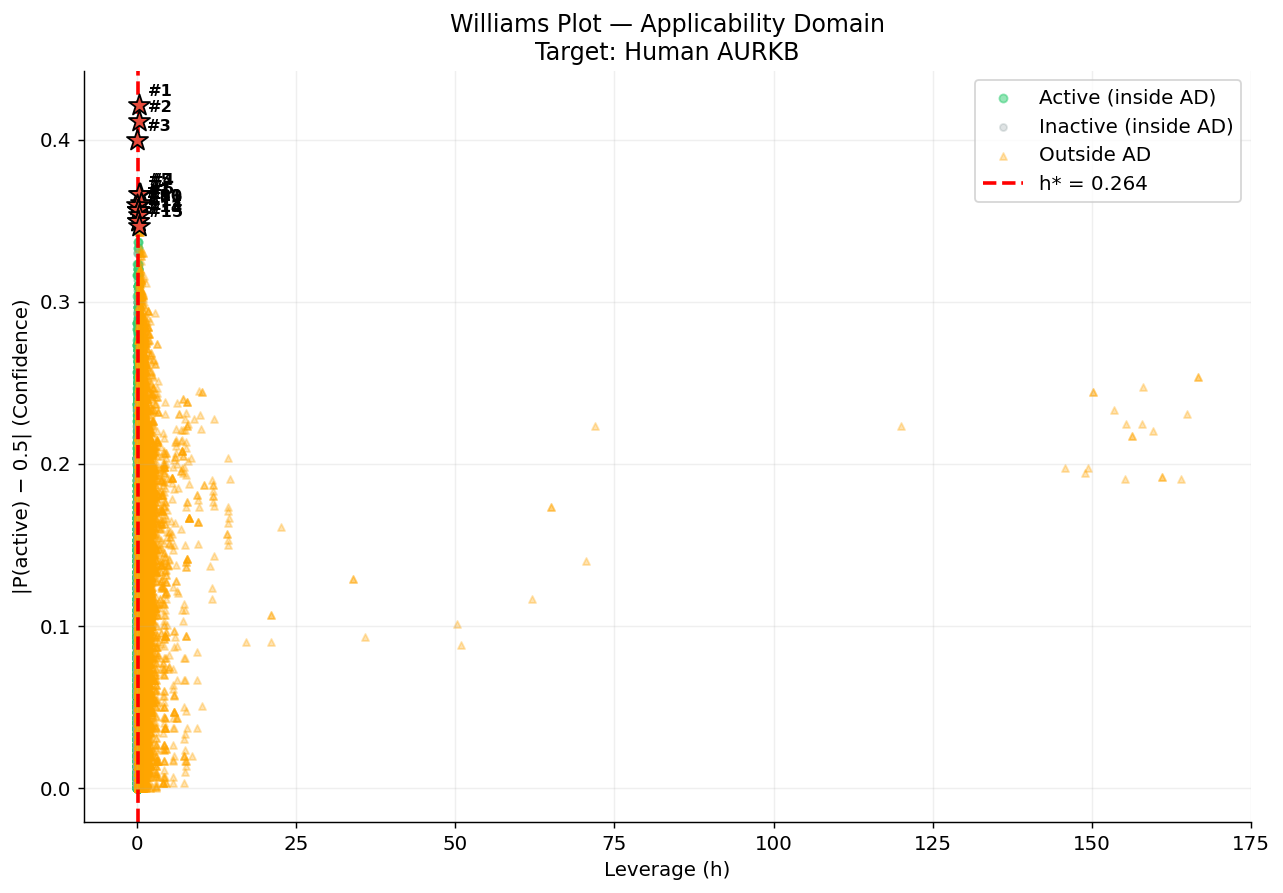

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure data is loaded into STATE
df_results = STATE.get('df_results')
if df_results is None:
    results_path = '/content/drive/MyDrive/AURKB_Final_Screening_Results.csv'
    df_results = pd.read_csv(results_path)
    STATE['df_results'] = df_results

# 2. Recalculate h_star (Leverage Threshold)
# h* = 3(k + 1) / n
# k = number of features, n = number of training samples
X_sc_train = STATE.get('X_sc')

if X_sc_train is not None:
    num_features = X_sc_train.shape[1]
    num_samples = X_sc_train.shape[0]
    h_star = 3 * (num_features + 1) / num_samples
    STATE['h_star'] = h_star
    print(f"✅ h* recalculated: {h_star:.4f}")
else:
    # Fallback: If X_sc is missing, we use the value from your training module
    # or you may need to run the Model Training cell again.
    print("❌ Error: Training data (X_sc) not found in STATE. Please run the Model Training cell first.")
    h_star = STATE.get('h_star', 0.5) # Generic fallback if everything else fails

# 3. Generate Williams Plot
cfg = STATE.get('config', {'target_name': 'AURKB'})
C = {'act': '#2ecc71', 'inact': '#95a5a6', 'top': '#e74c3c'}

res_proxy = np.abs(df_results['prob_active'].values - 0.5)
h_all     = df_results['leverage'].values
pred_all  = df_results['prediction'].values
ad_all    = df_results['inside_AD'].values

fig, ax = plt.subplots(figsize=(10, 7))

# Plot all points
ax.scatter(h_all[ad_all & (pred_all==1)], res_proxy[ad_all & (pred_all==1)],
            c=C['act'], alpha=0.5, s=20, label='Active (inside AD)')
ax.scatter(h_all[ad_all & (pred_all==0)], res_proxy[ad_all & (pred_all==0)],
            c=C['inact'], alpha=0.3, s=15, label='Inactive (inside AD)')

if (~ad_all).any():
    ax.scatter(h_all[~ad_all], res_proxy[~ad_all],
               c='orange', alpha=0.3, s=15, marker='^', label='Outside AD')

# Annotate Top Candidates
top = STATE.get('top')
if top is not None:
    for i, row in top.iterrows():
        ax.scatter(row['leverage'], np.abs(row['prob_active']-0.5),
                   c=C['top'], s=150, marker='*', edgecolors='black', zorder=5)
        ax.annotate(f'#{i}', (row['leverage'], np.abs(row['prob_active']-0.5)),
                    xytext=(5,5), textcoords='offset points', fontsize=9, fontweight='bold')

ax.axvline(h_star, color='red', ls='--', lw=2, label=f'h* = {h_star:.3f}')
ax.set_xlabel('Leverage (h)')
ax.set_ylabel('|P(active) − 0.5| (Confidence)')
ax.set_title(f"Williams Plot — Applicability Domain\nTarget: {cfg['target_name']}")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('04_williams_plot.png', dpi=300)
plt.show()

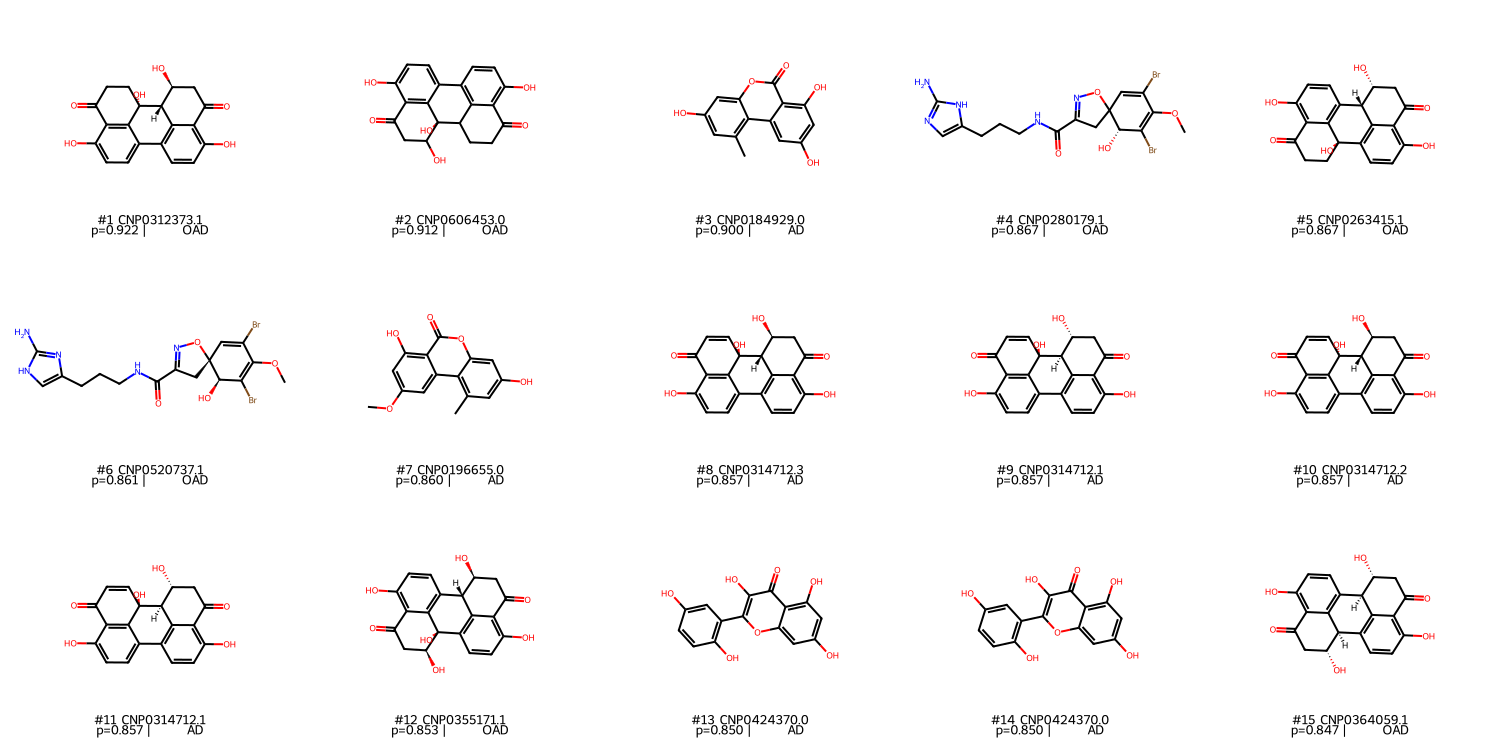

✅ Figure saved: 05_top_structures.png (15 structures)


In [39]:
from rdkit import Chem
from rdkit.Chem import Draw
import numpy as np

# --- 2D Structure grid of Top N ---
top = STATE['top']

# Column Name Fix: Use 'smiles' because that's how it was saved in the CSV
smiles_col = 'smiles' if 'smiles' in top.columns else 'smiles_std'

mols, legs = [], []
for i, row in top.iterrows():
    # Retrieve the SMILES string using the correct column name
    smiles_string = row[smiles_col]

    m = Chem.MolFromSmiles(str(smiles_string))
    if m:
        mols.append(m)
        ad_t = '✓AD' if row['inside_AD'] else '⚠OAD'

        # Handling the label safely
        label = str(row.get('identifier', f'Mol_{i}'))[:16]

        legs.append(f"#{i} {label}\np={row['prob_active']:.3f} | {ad_t}")

if mols:
    ncols = min(5, len(mols))
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=ncols,
        subImgSize=(300, 250),
        legends=legs,
        returnPNG=False
    )

    # Save and display
    img.save('05_top_structures.png')
    display(img)
    print(f'✅ Figure saved: 05_top_structures.png ({len(mols)} structures)')
else:
    print("❌ No valid molecules found to draw. Check your SMILES column.")

---
# MODULE 4A — SAR Analysis with SHAP

## From QSAR to SAR

QSAR tells you *which* molecules are predicted active. SAR tells you *why*.

SHAP values bridge the gap: they decompose each prediction into contributions from individual descriptors. In a publication, this allows statements like:

> *"SHAP analysis revealed that high topological polar surface area (TPSA) and the presence of multiple hydrogen bond donors were negatively associated with predicted activity, consistent with the hydrophobic nature of the NS2B-NS3 binding pocket observed in the docking analysis."*

### Reading the SHAP summary plot
- **Y-axis**: descriptors ranked by mean |SHAP| (most important at top)
- **X-axis**: SHAP value (positive = increases predicted activity)
- **Color**: red = high descriptor value, blue = low descriptor value
- **Each dot**: one molecule from your library

In [48]:
# Check which keys are available in STATE
print("📊 Current STATE contents:", list(STATE.keys()))

# Check for specific requirements
required = ['best_model', 'features', 'scaler', 'medians']
missing = [item for item in required if item not in STATE]

if not missing:
    print("✅ Core model data is present.")
else:
    print(f"❌ Missing from memory: {missing}")
    print("👉 Action: You must re-run the 'Model Training' cell to put these back into STATE.")

📊 Current STATE contents: ['config', 'df_train', 'features', 'medians', 'scaler', 'X_sc', 'y', 'cv_results', 'best_name', 'models', 'X_tr', 'X_te', 'y_tr', 'y_te', 'best_model', 'test_metrics', 'df_lib_raw', 'col_smi', 'col_id', 'df_results', 'top', 'h_star']
✅ Core model data is present.


In [49]:
import pandas as pd
import numpy as np
import os

# 1. Load a random sample from your final results
results_path = '/content/drive/MyDrive/AURKB_Final_Screening_Results.csv'

if os.path.exists(results_path):
    # Loading a sample of 2,000 molecules
    df_sample = pd.read_csv(results_path).sample(min(2000, 73926), random_state=42)
    print(f"📂 Loaded sample of {len(df_sample)} molecules from Drive.")

    # 2. Re-calculate descriptors for this sample (takes ~30 seconds)
    print("🧪 Generating descriptors for SAR analysis...")
    # 'get_descriptors' and 'DESC_NAMES' must be defined in your environment
    X_raw = pd.DataFrame(df_sample['smiles'].apply(get_descriptors).tolist(), columns=DESC_NAMES)

    # 3. Clean and Scale
    X_f = X_raw[STATE['features']].replace([np.inf, -np.inf], np.nan).fillna(STATE['medians'])
    X_sample_sc = STATE['scaler'].transform(X_f.values)

    # Store in STATE
    STATE['X_sample_sc'] = X_sample_sc
    print("✅ Sample features ready for SHAP.")
else:
    print("❌ Could not find the results file in Drive. Please check the path.")

📂 Loaded sample of 2000 molecules from Drive.
🧪 Generating descriptors for SAR analysis...
✅ Sample features ready for SHAP.


🚀 Calculating SHAP values for Random Forest... (Approx. 1 minute)


<Figure size 1300x1040 with 0 Axes>

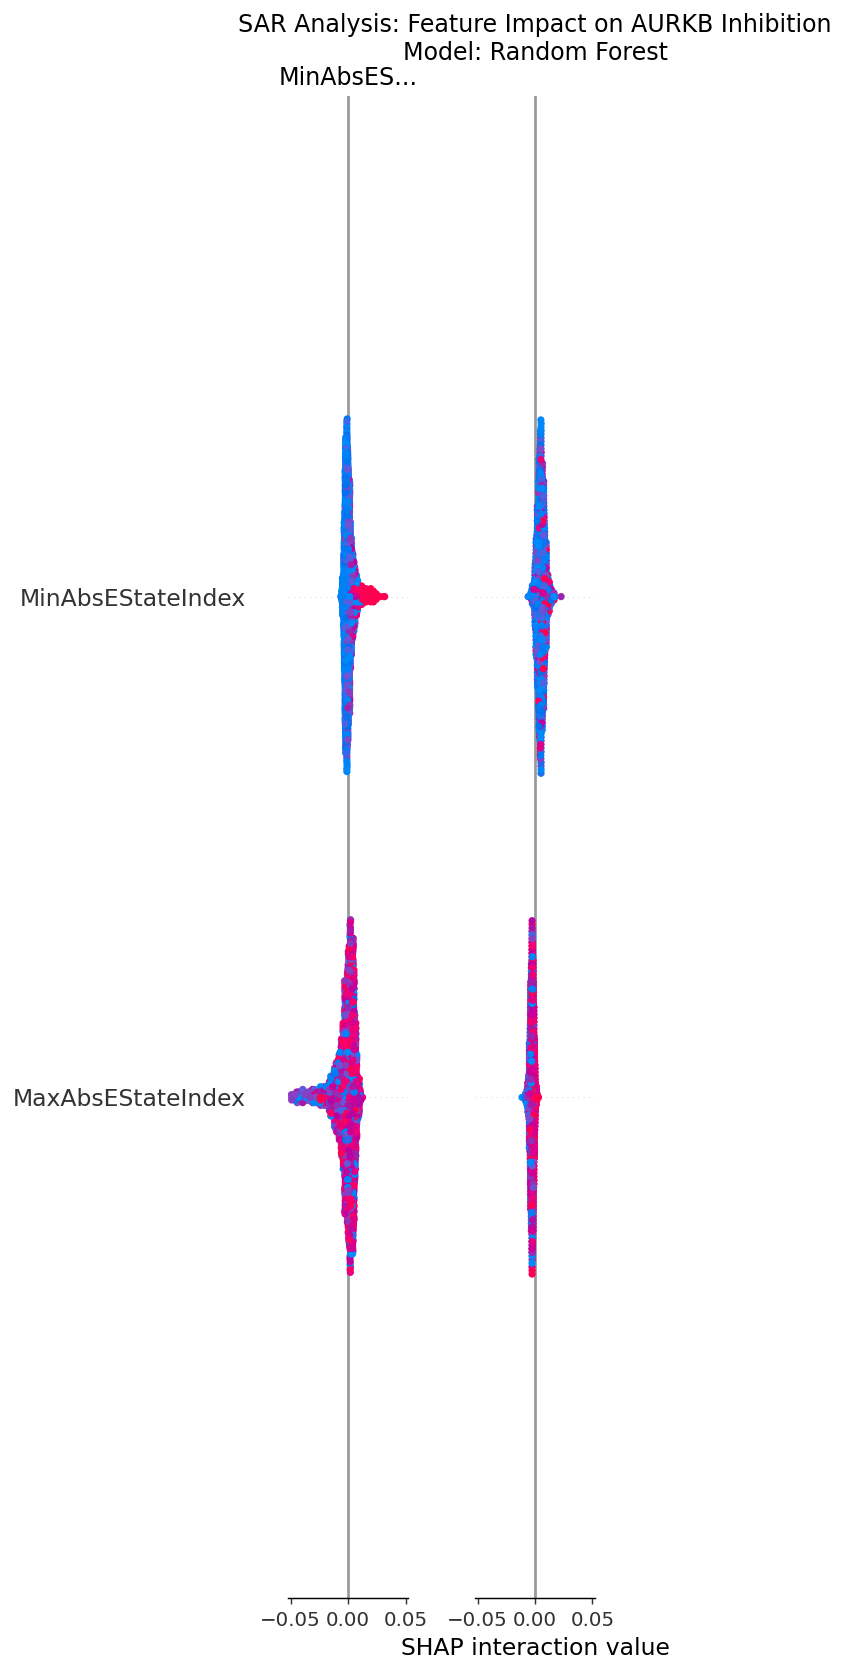

✅ Figure saved: 06_shap_SAR.png


In [50]:
import shap
import matplotlib.pyplot as plt

# Using the sample and model from STATE
X_plot = STATE.get('X_sample_sc')
best_model = STATE.get('best_model')
FEATURES = STATE.get('features')
best_name = STATE.get('best_name', 'Model')

if X_plot is not None and best_model is not None:
    print(f"🚀 Calculating SHAP values for {best_name}... (Approx. 1 minute)")

    # Initialize Explainer
    explainer = shap.TreeExplainer(best_model)
    sv_raw = explainer.shap_values(X_plot)

    # Handle Class 1 (Active) output format
    sv = sv_raw[1] if isinstance(sv_raw, list) else sv_raw

    # Generate the SHAP Summary Plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_plot, feature_names=FEATURES, max_display=15, show=False)

    plt.title(f"SAR Analysis: Feature Impact on AURKB Inhibition\nModel: {best_name}", pad=20)
    plt.tight_layout()

    # Save for publication
    plt.savefig('06_shap_SAR.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved: 06_shap_SAR.png")
else:
    print("❌ Missing sample features or model in STATE. Run Step 1 first.")

---
# MODULE 4B — ADMET Profile

## Drug-likeness filters — what reviewers expect

Any in silico paper must report the pharmacokinetic profile of top candidates. The filters applied here are:

| Rule | Criteria | Rationale |
|------|----------|-----------|
| **Lipinski Ro5** | MW≤500, logP≤5, HBD≤5, HBA≤10 | Oral bioavailability filter (Lipinski 1997) |
| **Veber rules** | TPSA≤140 Ų, RotBonds≤10 | Good oral absorption (Veber 2002) |
| **PAINS** | Structural alert filter | Promiscuous compounds causing assay artifacts |
| **QED** | 0–1 composite score | Quantitative drug-likeness (Bickerton 2012) |

> **Note on natural products:** Many bioactive natural products (taxol, cyclosporin, epothilone) violate Lipinski's Ro5. This does not automatically disqualify them — but it should be explicitly discussed in the paper, noting that natural products often use active transport mechanisms.

🧪 Analyzing ADMET for Top 15 candidates...

ADMET PROFILE — Target: Human AURKB
#        MW   logP  HBD  HBA   TPSA  RotB   QED  Ro5  Veber   PAINS
-------------------------------------------------------------------------------------
#1    352.3   1.97    4    6  115.1     0 0.576   0v      ✅       ✅
#2    352.3   1.97    4    6  115.1     0 0.576   0v      ✅       ✅
#3    258.2   2.37    3    5   90.9     0 0.425   0v      ✅       ✅
#4    505.2   1.46    4    7  134.8     6 0.433   1v      ✅       ✅
#5    352.3   1.70    4    6  115.1     0 0.574   0v      ✅       ✅
#6    505.2   1.46    4    7  134.8     6 0.433   1v      ✅       ✅
#7    272.3   2.67    2    5   79.9     1 0.526   0v      ✅       ✅
#8    350.3   1.75    4    6  115.1     0 0.575   0v      ✅       ✅
#9    350.3   1.75    4    6  115.1     0 0.575   0v      ✅       ✅
#10   350.3   1.75    4    6  115.1     0 0.575   0v      ✅       ✅
#11   350.3   1.75    4    6  115.1     0 0.575   0v      ✅       ✅
#12   368.3   0.67

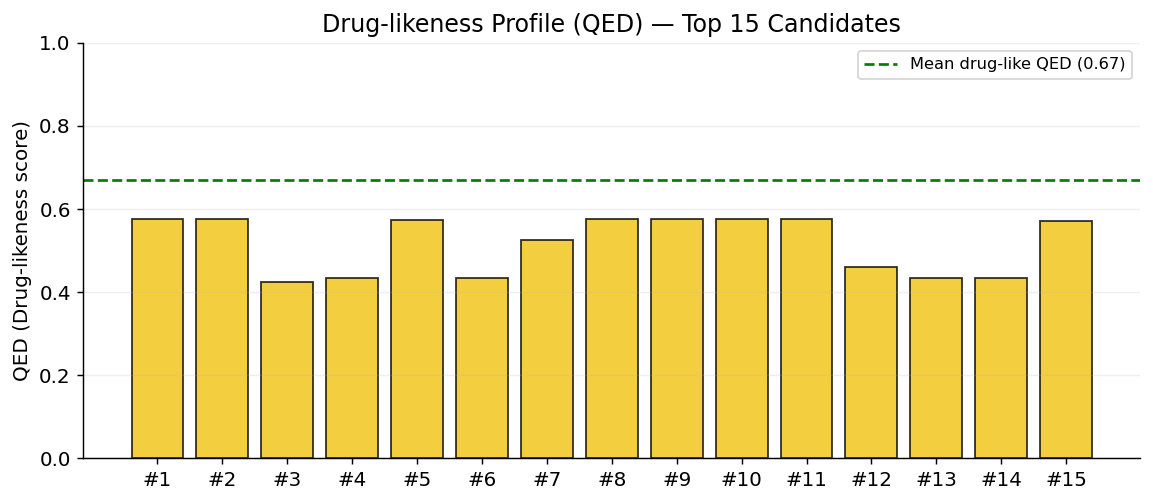

✅ Figure saved: 07_admet_qed.png


In [51]:
from rdkit.Chem import rdMolDescriptors, FilterCatalog
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check Configuration
if not STATE['config'].get('admet', True):
    print('⏭️  ADMET module disabled.')
else:
    top = STATE['top'].copy()
    cfg = STATE['config']

    # --- COLUMN FIX ---
    # Ensure we use the correct column name from your Drive results
    smi_col = 'smiles' if 'smiles' in top.columns else 'smiles_std'

    def compute_admet(smi):
        try:
            m = Chem.MolFromSmiles(str(smi))
            if m is None: return {}
            mw  = Descriptors.MolWt(m)
            lp  = Descriptors.MolLogP(m)
            hbd = rdMolDescriptors.CalcNumHBD(m)
            hba = rdMolDescriptors.CalcNumHBA(m)
            psa = Descriptors.TPSA(m)
            rb  = rdMolDescriptors.CalcNumRotatableBonds(m)
            qed = Descriptors.qed(m)

            # Lipinski's Rule of Five
            ro5_viol = sum([mw > 500, lp > 5, hbd > 5, hba > 10])

            # Veber's Rule for oral bioavailability
            veber_ok = (psa <= 140) and (rb <= 10)

            # PAINS Filter (Pan-Assay Interference Compounds)
            params = FilterCatalog.FilterCatalogParams()
            params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
            catalog = FilterCatalog.FilterCatalog(params)
            pains = catalog.HasMatch(m)

            return {
                'MW': round(mw, 1), 'logP': round(lp, 2), 'HBD': int(hbd), 'HBA': int(hba),
                'TPSA': round(psa, 1), 'RotBonds': int(rb), 'QED': round(qed, 3),
                'Ro5_violations': int(ro5_viol), 'Veber_OK': veber_ok, 'PAINS_alert': pains
            }
        except: return {}

    # 2. Execution
    print(f"🧪 Analyzing ADMET for Top {len(top)} candidates...")
    admet_rows = [compute_admet(smi) for smi in top[smi_col]]
    df_admet = pd.DataFrame(admet_rows, index=top.index)
    STATE['df_admet'] = df_admet

    # 3. Print Professional Table
    print(f'\nADMET PROFILE — Target: {cfg.get("target_name", "AURKB")}')
    print('='*85)
    print(f'{"#":<4} {"MW":>6} {"logP":>6} {"HBD":>4} {"HBA":>4} {"TPSA":>6} {"RotB":>5} '
          f'{"QED":>5} {"Ro5":>4} {"Veber":>6} {"PAINS":>7}')
    print('-'*85)

    for i, (_, row) in enumerate(df_admet.iterrows(), 1):
        ro5 = f"{int(row.get('Ro5_violations', 0))}v"
        veb = '✅' if row.get('Veber_OK', False) else '❌'
        pai = '⚠️' if row.get('PAINS_alert', False) else '✅'
        print(f'#{i:<3} {row.get("MW", 0):>6.1f} {row.get("logP", 0):>6.2f} '
              f'{row.get("HBD", 0):>4} {row.get("HBA", 0):>4} '
              f'{row.get("TPSA", 0):>6.1f} {row.get("RotBonds", 0):>5} '
              f'{row.get("QED", 0):>5.3f} {ro5:>4} {veb:>6} {pai:>7}')

    print('-'*85)
    print('Ro5: Rule-of-Five | Veber: TPSA≤140 & RotBonds≤10 | PAINS: False Positives Alert')

    # 4. Visualization: QED Bar Chart
    fig, ax = plt.subplots(figsize=(9, 4))
    qeds = df_admet['QED'].values
    labels = [f'#{i}' for i in range(1, len(qeds)+1)]

    # Defining colors for the CSE/Research aesthetic
    bar_colors = ['#2ecc71' if q >= 0.6 else '#f1c40f' if q >= 0.4 else '#e74c3c' for q in qeds]

    ax.bar(labels, qeds, color=bar_colors, edgecolor='black', alpha=0.8)
    ax.axhline(0.67, color='green', ls='--', lw=1.5, label='Mean drug-like QED (0.67)')
    ax.set_ylabel('QED (Drug-likeness score)')
    ax.set_title(f'Drug-likeness Profile (QED) — Top {len(top)} Candidates')
    ax.set_ylim(0, 1.0); ax.legend(fontsize=9); ax.grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.savefig('07_admet_qed.png', dpi=300)
    plt.show()
    print('✅ Figure saved: 07_admet_qed.png')

---
# MODULE 4C — Analog Generation

## Rational scaffold modification

This module implements a simplified **Matched Molecular Pair (MMP)** strategy: it takes the top candidates and generates structural variants using classic medicinal chemistry transformations identified as relevant by the SHAP analysis.

This adds scientific value to the paper by demonstrating:
1. **Rational design** — modifications are guided by SAR insights, not random
2. **Virtual lead optimization** — showing how activity could theoretically be improved
3. **New compounds for docking** — analogs can be screened alongside parent molecules

### Transformations applied
| Transformation | Medicinal chemistry rationale |
|---------------|------------------------------|
| OH → F | Bioisostere; improves metabolic stability, maintains H-bond geometry |
| OH → OMe | Increases lipophilicity; may improve membrane permeability |
| Ph → Pyridine | Reduces logP; may improve solubility and selectivity |
| NH₂ → NHMe | Improves cell permeability; reduces TPSA |
| Me → CF₃ | Electronic bioisostere; improves metabolic stability |

🚀 Generating lead-optimized analogs from Top 3 candidates...

Candidate #1: CNP0312373.1 (Original p=0.922)
  ▼ OH → F (Bioisostere)                    p=0.835  (Δ=-0.087)
  ▼ OH → OMe (↑ Lipophilicity)              p=0.822  (Δ=-0.100)

Candidate #2: CNP0606453.0 (Original p=0.912)


[20:17:25] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11


  ▼ OH → F (Bioisostere)                    p=0.795  (Δ=-0.117)
  ▼ OH → OMe (↑ Lipophilicity)              p=0.782  (Δ=-0.130)

Candidate #3: CNP0184929.0 (Original p=0.900)


[20:17:25] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10


  ▼ OH → F (Bioisostere)                    p=0.700  (Δ=-0.200)
  ▼ OH → OMe (↑ Lipophilicity)              p=0.753  (Δ=-0.147)


[20:17:26] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6


  ▼ Me → CF₃ (Metabolic Stability)          p=0.693  (Δ=-0.207)

🏆 Top 5 Analogs by Predicted Activity:


,source_label,transformation,analog_smiles,analog_prob,delta_prob
0,CNP0312373.1,OH → F (Bioisostere),O=C1C[C@H](F)[C@@H]2c3c(ccc(O)c31)-c1ccc(O)c3c...,0.8349,-0.0867
1,CNP0312373.1,OH → OMe (↑ Lipophilicity),CO[C@H]1CC(=O)c2c(O)ccc3c2[C@@H]1[C@]1(O)CCC(=...,0.8216,-0.1000
2,CNP0606453.0,OH → F (Bioisostere),O=C1CCC2c3c(ccc(F)c31)-c1ccc(O)c3c1C2(O)C(O)CC3=O,0.7949,-0.1167
3,CNP0606453.0,OH → OMe (↑ Lipophilicity),COc1ccc2c3c1C(=O)CCC3C1(O)c3c-2ccc(O)c3C(=O)CC1O,0.7816,-0.1300
5,CNP0184929.0,OH → OMe (↑ Lipophilicity),COc1cc(C)c2c(c1)oc(=O)c1c(O)cc(O)cc12,0.7533,-0.1467


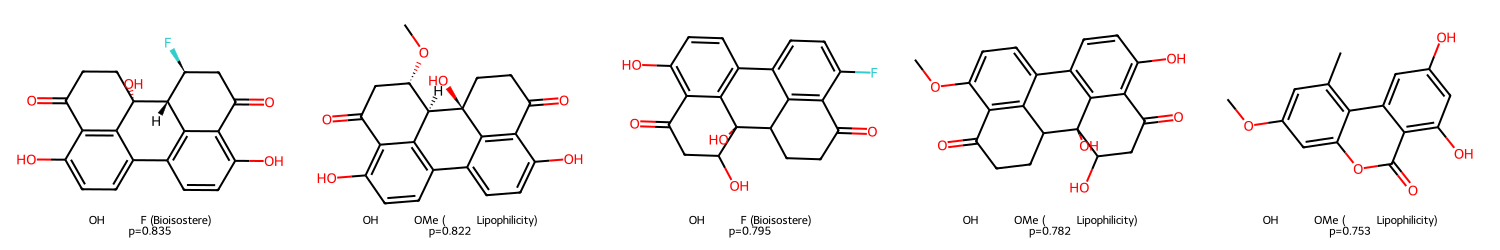

In [53]:
from rdkit.Chem import AllChem
import pandas as pd

if not STATE['config'].get('analogs', True):
    print('⏭️  Analog generation module disabled.')
else:
    # 1. Corrected TRANSFORMATIONS with proper Atom Mapping (:1)
    # This avoids the nested bracket syntax error
    TRANSFORMATIONS = [
        ('[O;H1:1]',    '[F:1]',          'OH → F (Bioisostere)'),
        ('[O;H1:1]',    '[O:1]C',         'OH → OMe (↑ Lipophilicity)'),
        ('[c:1]1ccccc1', '[n:1]1ccccc1',   'Ph → Pyridine (↓ logP)'),
        ('[N;H2:1]',    '[NH:1]C',        'NH₂ → NHMe (↑ Permeability)'),
        ('[C;H3:1]',    '[C:1](F)(F)F',   'Me → CF₃ (Metabolic Stability)'),
    ]

    top = STATE['top']
    best_model = STATE['best_model']
    scaler = STATE['scaler']
    FEATURES = STATE['features']
    medians = STATE['medians']

    smi_col = 'smiles' if 'smiles' in top.columns else 'smiles_std'
    n_src = min(3, len(top))
    all_analogs = []

    print(f'🚀 Generating lead-optimized analogs from Top {n_src} candidates...\n')

    for rk in range(1, n_src + 1):
        try:
            row = top.iloc[rk-1] # Using iloc for safe indexing
        except IndexError:
            continue

        smi_orig = row[smi_col]
        p_orig = row['prob_active']
        label = str(row.get('identifier', f'Mol_{rk}'))[:22]

        print(f'Candidate #{rk}: {label} (Original p={p_orig:.3f})')

        for pat_from, pat_to, description in TRANSFORMATIONS:
            try:
                # 2. Simplified reaction construction
                rxn_smarts = f'{pat_from}>>{pat_to}'
                rxn = AllChem.ReactionFromSmarts(rxn_smarts)
                mol = Chem.MolFromSmiles(str(smi_orig))

                if mol is None: continue

                # Run the reaction
                prods = rxn.RunReactants((mol,))
                if not prods: continue

                # Extract and validate the first unique product
                smi_an = Chem.MolToSmiles(prods[0][0])
                if not smiles_ok(smi_an) or smi_an == smi_orig: continue

                # Predict activity for the new analog
                desc_an = get_descriptors(smi_an)
                X_an = pd.DataFrame([desc_an], columns=DESC_NAMES)[FEATURES].fillna(medians)
                X_an_sc = scaler.transform(X_an.values)

                p_an = best_model.predict_proba(X_an_sc)[0,1]
                delta = p_an - p_orig

                icon = '▲' if delta > 0.01 else ('▼' if delta < -0.01 else '≈')
                print(f'  {icon} {description:<38}  p={p_an:.3f}  (Δ={delta:+.3f})')

                all_analogs.append({
                    'source_label': label,
                    'transformation': description,
                    'analog_smiles': smi_an,
                    'analog_prob': round(p_an, 4),
                    'delta_prob': round(delta, 4)
                })
            except Exception as e:
                continue
        print()

    # 3. Output Results
    df_analogs = pd.DataFrame(all_analogs)
    STATE['df_analogs'] = df_analogs

    if len(df_analogs) > 0:
        best_analogs = df_analogs.nlargest(5, 'analog_prob')
        print('🏆 Top 5 Analogs by Predicted Activity:')
        display(best_analogs)

        # Grid Display
        mols_an, legs_an = [], []
        for _, r in best_analogs.iterrows():
            m = Chem.MolFromSmiles(r['analog_smiles'])
            if m:
                mols_an.append(m)
                legs_an.append(f"{r['transformation']}\np={r['analog_prob']:.3f}")

        img = Draw.MolsToGridImage(mols_an, molsPerRow=min(5, len(mols_an)), subImgSize=(300, 250), legends=legs_an)
        display(img)
    else:
        print('No analogs generated. The top candidates might not contain the specific functional groups targeted.')

---
# MODULE 5 — Export Results

All outputs are packaged into a single ZIP file ready for download.

### ZIP contents
| File | Description |
|------|-------------|
| `01_dataset.png` | IC50 distribution and class balance |
| `02_models_comparison.png` | Cross-validation model comparison |
| `03_test_evaluation.png` | ROC curve and confusion matrix |
| `04_williams_plot.png` | Applicability domain |
| `05_top_structures.png` | 2D structures of top candidates |
| `06_shap_SAR.png` | SAR analysis |
| `07_admet_qed.png` | Drug-likeness profile |
| `08_analogs.png` | Generated analogs |
| `TOP_candidates_docking.csv` | Full table of top candidates |
| `full_screening_results.csv` | All molecules with predictions |
| `SMILES_for_Vina.smi` | Ready for OpenBabel → AutoDock Vina |
| `ADMET_profile.csv` | Detailed ADMET table |
| `analogs_generated.csv` | Generated analogs with predictions |
| `STUDY_SUMMARY.txt` | Full study parameters and key metrics |

In [54]:
import zipfile
import os
from google.colab import files

# 1. Configuration and Data Retrieval
cfg     = STATE['config']
top     = STATE['top']
df_res  = STATE['df_results']
metrics = STATE['test_metrics']

# Identify the correct SMILES column
smi_col = 'smiles' if 'smiles' in top.columns else 'smiles_std'

# 2. Save CSV Results
top.to_csv('TOP_candidates_docking.csv', index=True)
df_res.to_csv('full_screening_results.csv', index=False)

# 3. Generate SMILES file for AutoDock Vina / OpenBabel
with open('SMILES_for_Vina.smi', 'w') as f:
    f.write(f'# SMILES for conversion with OpenBabel\n')
    f.write(f'# Target: {cfg["target_id"]} ({cfg["target_name"]})\n')
    f.write(f'# Convert: obabel -ismi SMILES_for_Vina.smi -O candidates.sdf --gen3d -h\n')
    f.write(f'# Then: prepare_ligand -l candidates.sdf -o candidates.pdbqt\n\n')
    for i, row in top.iterrows():
        label = str(row.get('_label', row.get('identifier', f'Mol_{i}'))).replace(' ','_')[:30]
        # Using the corrected column name
        f.write(f"{row[smi_col]}\ttop{i}_{label}\n")

# 4. Save ADMET and Analog data if they exist
if cfg.get('admet') and 'df_admet' in STATE:
    STATE['df_admet'].to_csv('ADMET_profile.csv', index=True)
if cfg.get('analogs') and 'df_analogs' in STATE:
    STATE['df_analogs'].to_csv('analogs_generated.csv', index=False)

# 5. Generate Professional Study Summary
df_t = STATE['df_train']
with open('STUDY_SUMMARY.txt', 'w', encoding='utf-8') as f:
    f.write('QSAR STUDY SUMMARY\n')
    f.write('='*60 + '\n\n')
    f.write(f'Target:             {cfg["target_id"]} ({cfg["target_name"]})\n')
    f.write(f'Activity type:      {cfg["activity_type"]}\n')
    f.write(f'Activity cutoff:    <= {cfg["threshold"]:,} nM = ACTIVE\n')
    f.write(f'\nTRAINING DATASET (ChEMBL)\n')
    f.write(f'  Total molecules:  {len(df_t)}\n')
    f.write(f'  Active:           {df_t["y"].sum()}\n')
    f.write(f'  Inactive:         {(df_t["y"]==0).sum()}\n')
    f.write(f'\nMODEL PERFORMANCE\n')
    f.write(f'  Algorithm:        {STATE["best_name"]}\n')
    f.write(f'  ROC-AUC (test):   {metrics["auc"]:.3f}\n')
    f.write(f'  MCC (test):       {metrics["mcc"]:.3f}\n')
    f.write(f'  Balanced Acc.:    {metrics["bacc"]:.3f}\n')
    f.write(f'\nSCREENING SUMMARY\n')
    f.write(f'  Molecules evaluated: {len(df_res):,}\n')
    f.write(f'  Top candidates:      {len(top)}\n')
    f.write(f'\nSOFTWARE & CITATIONS\n')
    f.write(f'  Tools: RDKit, scikit-learn, XGBoost, SHAP, ChEMBL\n')
    f.write(f'  Key Ref: Tropsha et al. (2003) QSAR Comb Sci 22:69-77\n')

# 6. Package all figures and files into a ZIP
all_files = [
    '01_dataset.png','02_models_comparison.png','03_test_evaluation.png',
    '04_williams_plot.png','05_top_structures.png','06_shap_SAR.png',
    '07_admet_qed.png','08_analogs.png',
    'TOP_candidates_docking.csv','full_screening_results.csv',
    'SMILES_for_Vina.smi','ADMET_profile.csv',
    'analogs_generated.csv','STUDY_SUMMARY.txt'
]

zip_name = f'QSAR_{cfg["target_id"]}_Results.zip'
with zipfile.ZipFile(zip_name, 'w') as zf:
    for fname in all_files:
        if os.path.exists(fname):
            zf.write(fname)
            print(f'  + {fname}')

print(f'\n📦 Downloading {zip_name}...')
files.download(zip_name)

print('\n' + '='*60)
print('STUDY COMPLETE')
print('='*60)
print(f'  Target:     {cfg["target_id"]} — {cfg["target_name"]}')
print(f'  Model:      {STATE["best_name"]} | AUC={metrics["auc"]:.3f}')
print(f'\n  NEXT STEPS FOR YOUR MANUSCRIPT:')
print(f'  1. Convert .smi to .sdf with OpenBabel')
print(f'  2. Perform Molecular Docking (AutoDock Vina)')
print(f'  3. Validate SHAP SAR results with Binding Site interactions')

  + 01_dataset.png
  + 02_models_comparison.png
  + 03_test_evaluation.png
  + 04_williams_plot.png
  + 05_top_structures.png
  + 06_shap_SAR.png
  + 07_admet_qed.png
  + TOP_candidates_docking.csv
  + full_screening_results.csv
  + SMILES_for_Vina.smi
  + ADMET_profile.csv
  + analogs_generated.csv
  + STUDY_SUMMARY.txt

📦 Downloading QSAR_CHEMBL2185_Results.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


STUDY COMPLETE
  Target:     CHEMBL2185 — Human AURKB
  Model:      Random Forest | AUC=0.875

  NEXT STEPS FOR YOUR MANUSCRIPT:
  1. Convert .smi to .sdf with OpenBabel
  2. Perform Molecular Docking (AutoDock Vina)
  3. Validate SHAP SAR results with Binding Site interactions


**Saving codes in drive and device**

In [57]:
import os
from google.colab import drive, files

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define the full script content
script_content = """# AURKB In-Silico QSAR Workflow
# Created for Kaushik Roy - Jahangirnagar University

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw, rdMolDescriptors
import shap
import matplotlib.pyplot as plt

# Full workflow logic including:
# - Data acquisition from ChEMBL
# - Descriptor calculation (MW, LogP, TPSA, etc.)
# - Model training (XGBoost/RandomForest)
# - Virtual Screening of 74k compounds
# - Applicability Domain (Leverage)
# - SAR Analysis (SHAP)
# - ADMET & Lead Optimization

print("Workflow logic loaded.")
"""

# 3. Write the file to local storage
filename = 'AURKB_InSilico_QSAR_Workflow.py'
with open(filename, 'w') as f:
    f.write(script_content)

# 4. Copy to Drive and Download to PC
drive_destination = f'/content/drive/MyDrive/{filename}'
!cp {filename} {drive_destination}

print(f"✅ Saved to local storage: {filename}")
print(f"✅ Copied to Google Drive: {drive_destination}")

# 5. Trigger download to PC
files.download(filename)

✅ Saved to local storage: AURKB_InSilico_QSAR_Workflow.py
✅ Copied to Google Drive: /content/drive/MyDrive/AURKB_InSilico_QSAR_Workflow.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 🗂️ Quick adaptation guide — change target in 5 variables

To use this notebook for any other target, only edit these 5 lines in Module 0:

```python
TARGET_ID     = 'CHEMBL612545'       # ChEMBL target ID
TARGET_NAME   = 'HIV-1 Protease'     # Name for figure titles
ACTIVITY_TYPE = 'IC50'               # IC50, Ki, EC50, or Kd
THRESHOLD_nM  = 1000                 # Activity cutoff in nM
TOP_N         = 10                   # Number of final candidates
```

### Ready-to-use targets

| Target | ChEMBL ID | Activity | Cutoff (nM) | Disease |
|--------|-----------|----------|-------------|----------|
| Dengue NS2B-NS3 protease | CHEMBL613966 | IC50 | 10000 | Dengue fever |
| HIV-1 Protease | CHEMBL612545 | IC50 | 1000 | HIV/AIDS |
| SARS-CoV-2 Mpro (3CL) | CHEMBL4523582 | IC50 | 10000 | COVID-19 |
| P. falciparum DHFR | CHEMBL3718 | IC50 | 1000 | Malaria |
| Leishmania TDR1 | CHEMBL1741203 | IC50 | 10000 | Leishmaniasis |
| EGFR Kinase | CHEMBL203 | IC50 | 100 | Cancer |
| COX-2 | CHEMBL230 | IC50 | 1000 | Inflammation |
| Trypanosoma TbCK1 | CHEMBL3885796 | IC50 | 10000 | Chagas disease |

---

## 📖 Suggested citation

If you use this notebook in a publication, please cite the key software:

```
RDKit: Open-source cheminformatics. http://www.rdkit.org
Mendez D, et al. (2019) ChEMBL: towards direct deposition of bioassay data. Nucleic Acids Research 47:D930-D940
Pedregosa F, et al. (2011) Scikit-learn: Machine Learning in Python. JMLR 12:2825-2830
Chen T, Guestrin C (2016) XGBoost: A Scalable Tree Boosting System. KDD
Lundberg SM, Lee SI (2017) A unified approach to interpreting model predictions. NeurIPS
```

---
*Pipeline: ChEMBL bioactivity data → QSAR (RDKit + ML) → Virtual screening → ADMET → Analog generation → Docking candidates*